<a href="https://colab.research.google.com/github/prksh830/Healthcare/blob/main/HDP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Preprocessing
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
    matthews_corrcoef, cohen_kappa_score,
    log_loss, brier_score_loss, classification_report,
    precision_recall_curve, auc
)

# Feature Selection
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Baselines
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.regularizers import l2

# Optimization
!pip install optuna
!pip install optuna-integration[tfkeras]
import optuna
from optuna.integration import TFKerasPruningCallback

# SHAP
import shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 kB 8.7 MB/s eta 0:00:00


In [4]:
df = pd.read_csv("heart.csv")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (1025, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [5]:
X = df.drop("target", axis=1)
y = df["target"]

In [6]:
# Remove duplicates
df = df.drop_duplicates()

# Check missing values
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [8]:
selector = SelectKBest(mutual_info_classif, k=int(X.shape[1]*0.8))
X_selected = selector.fit_transform(X_scaled, y)

selected_features = X.columns[selector.get_support()]
print("Selected Features:", selected_features)

Selected Features: Index(['age', 'cp', 'trestbps', 'chol', 'thalach', 'exang', 'oldpeak', 'slope',
       'ca', 'thal'],
      dtype='object')


In [9]:
def build_model(input_dim, trial):

    n_units = trial.suggest_int("units", 32, 128)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)
    l2_reg = trial.suggest_loguniform("l2", 1e-5, 1e-2)

    inputs = keras.Input(shape=(input_dim,))

    x = layers.Dense(n_units, activation="relu",
                     kernel_regularizer=l2(l2_reg))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)

    # Residual block
    shortcut = x
    x = layers.Dense(n_units, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([x, shortcut])
    x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)

    optimizer = tf.keras.optimizers.AdamW(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["AUC"]
    )

    return model

In [11]:
def objective(trial):

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    auc_scores = []

    for train_idx, val_idx in skf.split(X_selected, y):

        X_train, X_val = X_selected[train_idx], X_selected[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = build_model(X_selected.shape[1], trial)

        early = keras.callbacks.EarlyStopping(
            patience=10, restore_best_weights=True)

        model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=100,
            batch_size=trial.suggest_categorical("batch", [16, 32, 64]),
            verbose=0,
            callbacks=[early]
        )

        preds = model.predict(X_val).ravel()
        auc_scores.append(roc_auc_score(y_val, preds))

    return np.mean(auc_scores)


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print("Best Params:", study.best_params)

[I 2026-02-15 15:48:44,909] A new study created in memory with name: no-name-8cd744aa-969f-434f-bfb0-25c06f8dd0a2


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


[I 2026-02-15 15:53:19,276] Trial 0 finished with value: 0.9372803234501348 and parameters: {'units': 45, 'dropout': 0.3968913205755912, 'lr': 0.00013467378682093228, 'l2': 0.00474269319944056, 'batch': 16}. Best is trial 0 with value: 0.9372803234501348.


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


[I 2026-02-15 15:56:03,685] Trial 1 finished with value: 0.9867532804123099 and parameters: {'units': 70, 'dropout': 0.4927465062743669, 'lr': 0.0023068088178356265, 'l2': 0.006917490169626408, 'batch': 32}. Best is trial 1 with value: 0.9867532804123099.


...

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


[I 2026-02-15 16:17:39,229] Trial 8 finished with value: 0.9954460324042534 and parameters: {'units': 67, 'dropout': 0.22970397627479247, 'lr': 0.007876897279168854, 'l2': 9.905966478679908e-05, 'batch': 16}. Best is trial 6 with value: 1.0.


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


[I 2026-02-15 16:21:15,956] Trial 9 finished with value: 0.9999230769230769 and parameters: {'units': 111, 'dropout': 0.2068649640016824, 'lr': 0.0012521379867365373, 'l2': 2.1006024249250003e-05, 'batch': 16}. Best is trial 6 with value: 1.0.


Best Params: {'units': 118, 'dropout': 0.10746459520880935, 'lr': 0.0003174288360150515, 'l2': 0.007198395593570281, 'batch': 32}


In [12]:
best_params = study.best_params
final_model = build_model(X_selected.shape[1], study.best_trial)

final_model.fit(X_selected, y,
                epochs=100,
                batch_size=best_params["batch"],
                verbose=0)

In [13]:
models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True),
    "RandomForest": RandomForestClassifier(n_estimators=100, n_jobs=-1),
    "XGBoost": XGBClassifier(eval_metric="logloss", use_label_encoder=False),
    "LightGBM": LGBMClassifier(),
    "GradientBoost": GradientBoostingClassifier()
}

In [14]:
results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_selected, y,
                             cv=10, scoring="roc_auc")
    results[name] = scores.mean()

print(results)

[LightGBM] [Info] Number of positive: 473, number of negative: 449
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000182 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 375
[LightGBM] [Info] Number of data points in the train set: 922, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.513015 -> initscore=0.052073
[LightGBM] [Info] Start training from score 0.052073
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 473, number of negative: 44

In [15]:
pred_probs = final_model.predict(X_selected).ravel()
preds = (pred_probs > 0.5).astype(int)

print("Accuracy:", accuracy_score(y, preds))
print("MCC:", matthews_corrcoef(y, preds))
print("Kappa:", cohen_kappa_score(y, preds))
print("LogLoss:", log_loss(y, pred_probs))
print("Brier:", brier_score_loss(y, pred_probs))

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Accuracy: 1.0
MCC: 1.0
Kappa: 1.0
LogLoss: 0.004543649745085212
Brier: 0.00012798079263419293


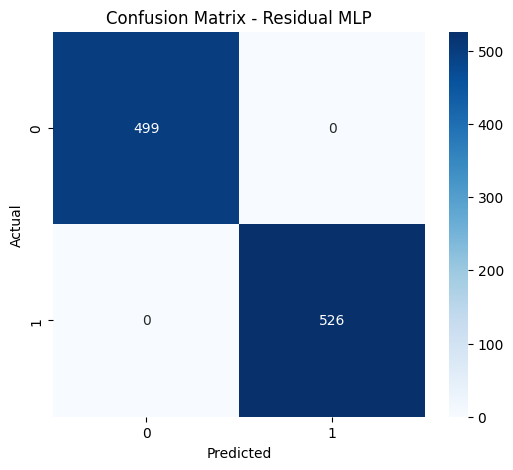

In [16]:
cm = confusion_matrix(y, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Residual MLP")
plt.show()

[LightGBM] [Info] Number of positive: 526, number of negative: 499
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000060 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 400
[LightGBM] [Info] Number of data points in the train set: 1025, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.513171 -> initscore=0.052695
[LightGBM] [Info] Start training from score 0.052695
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


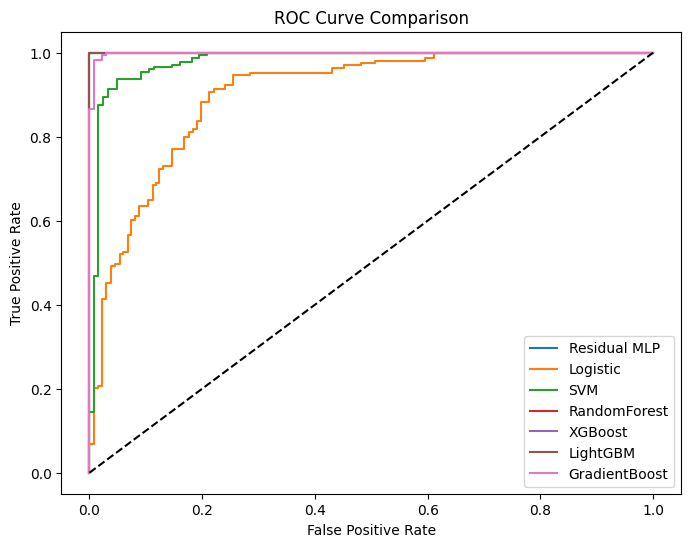

In [17]:
plt.figure(figsize=(8,6))

# DL model
fpr, tpr, _ = roc_curve(y, pred_probs)
plt.plot(fpr, tpr, label="Residual MLP")

# Baselines
for name, model in models.items():
    model.fit(X_selected, y)
    probs = model.predict_proba(X_selected)[:,1]
    fpr, tpr, _ = roc_curve(y, probs)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title("ROC Curve Comparison")
plt.show()

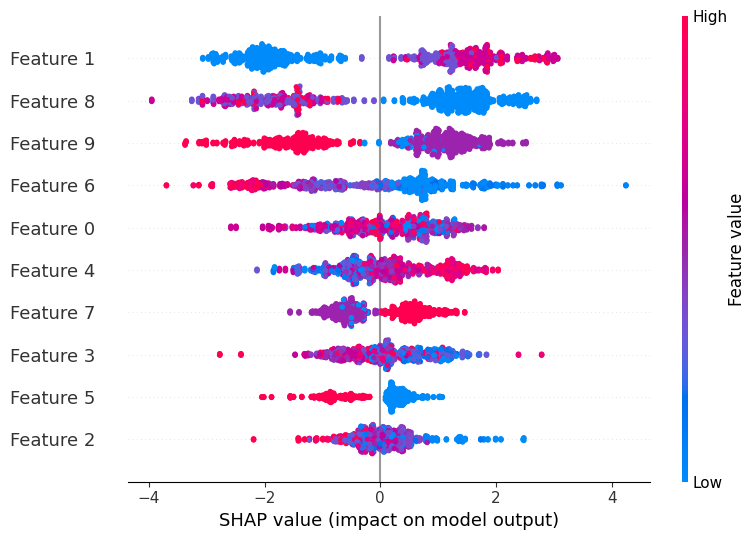

In [18]:
xgb = XGBClassifier()
xgb.fit(X_selected, y)

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_selected)

shap.summary_plot(shap_values, X_selected)

In [19]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

def evaluate_model_cv(model, X, y, is_dl=False):

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    y_true_all = []
    y_prob_all = []

    for train_idx, val_idx in skf.split(X, y):

        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        if is_dl:
            model.fit(X_train, y_train,
                      epochs=50,
                      batch_size=32,
                      verbose=0)
            y_prob = model.predict(X_val).ravel()
        else:
            clf = clone(model)
            clf.fit(X_train, y_train)
            y_prob = clf.predict_proba(X_val)[:,1]

        y_true_all.extend(y_val)
        y_prob_all.extend(y_prob)

    y_true_all = np.array(y_true_all)
    y_prob_all = np.array(y_prob_all)
    y_pred_all = (y_prob_all > 0.5).astype(int)

    precision, recall, _ = precision_recall_curve(y_true_all, y_prob_all)

    metrics = {
        "Accuracy": accuracy_score(y_true_all, y_pred_all),
        "ROC-AUC": roc_auc_score(y_true_all, y_prob_all),
        "MCC": matthews_corrcoef(y_true_all, y_pred_all),
        "F1": f1_score(y_true_all, y_pred_all),
        "LogLoss": log_loss(y_true_all, y_prob_all),
        "PR-AUC": auc(recall, precision)
    }

    return metrics

In [20]:
dl_metrics = evaluate_model_cv(final_model, X_selected, y, is_dl=True)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [21]:
comparison_results = {}

comparison_results["Residual MLP"] = dl_metrics

for name, model in models.items():
    comparison_results[name] = evaluate_model_cv(model, X_selected, y)

[LightGBM] [Info] Number of positive: 473, number of negative: 449
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000216 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 379
[LightGBM] [Info] Number of data points in the train set: 922, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.513015 -> initscore=0.052073
[LightGBM] [Info] Start training from score 0.052073
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

In [22]:
comparison_df = pd.DataFrame(comparison_results).T

# Sort by ROC-AUC
comparison_df = comparison_df.sort_values(by="ROC-AUC", ascending=False)

comparison_df

,Accuracy,ROC-AUC,MCC,F1,LogLoss,PR-AUC
LightGBM,1.000000,1.000000,1.000000,1.000000,0.004123,1.000000
XGBoost,1.000000,1.000000,1.000000,1.000000,0.013057,1.000000
RandomForest,1.000000,1.000000,1.000000,1.000000,0.038957,1.000000
Residual MLP,1.000000,1.000000,1.000000,1.000000,0.000409,1.000000
GradientBoost,0.974634,0.993965,0.949235,0.975332,0.149217,0.994460
SVM,0.908293,0.962739,0.816793,0.912150,0.246246,0.954558
Logistic,0.834146,0.895994,0.669996,0.845173,0.396395,0.880057


In [23]:
def highlight_best(s):
    is_max = s == s.max()
    return ['background-color: lightgreen' if v else '' for v in is_max]

comparison_df.style.apply(highlight_best)

,Accuracy,ROC-AUC,MCC,F1,LogLoss,PR-AUC
LightGBM,1.000000,1.000000,1.000000,1.000000,0.004123,1.000000
XGBoost,1.000000,1.000000,1.000000,1.000000,0.013057,1.000000
RandomForest,1.000000,1.000000,1.000000,1.000000,0.038957,1.000000
Residual MLP,1.000000,1.000000,1.000000,1.000000,0.000409,1.000000
GradientBoost,0.974634,0.993965,0.949235,0.975332,0.149217,0.994460
SVM,0.908293,0.962739,0.816793,0.912150,0.246246,0.954558
Logistic,0.834146,0.895994,0.669996,0.845173,0.396395,0.880057


In [24]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
import time

def evaluate_model_with_folds(model, X, y, is_dl=False):

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    fold_aucs = []
    fold_times = []
    y_true_all = []
    y_prob_all = []

    for train_idx, val_idx in skf.split(X, y):

        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        start = time.time()

        if is_dl:
            model.fit(X_train, y_train,
                      epochs=50,
                      batch_size=32,
                      verbose=0)
            y_prob = model.predict(X_val).ravel()
        else:
            clf = clone(model)
            clf.fit(X_train, y_train)
            y_prob = clf.predict_proba(X_val)[:,1]

        end = time.time()

        fold_aucs.append(roc_auc_score(y_val, y_prob))
        fold_times.append(end - start)

        y_true_all.extend(y_val)
        y_prob_all.extend(y_prob)

    return {
        "fold_aucs": fold_aucs,
        "mean_auc": np.mean(fold_aucs),
        "std_auc": np.std(fold_aucs),
        "runtime": np.mean(fold_times),
        "y_true": np.array(y_true_all),
        "y_prob": np.array(y_prob_all)
    }

In [25]:
results_detailed = {}

results_detailed["Residual MLP"] = evaluate_model_with_folds(
    final_model, X_selected, y, is_dl=True)

for name, model in models.items():
    results_detailed[name] = evaluate_model_with_folds(
        model, X_selected, y)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
[LightGBM] [Info] Number of positive: 473, number of negative: 449
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000072 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 379
[LightGBM] [Info] Number of data points in the train set: 922, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.513015 -> initscore=0.052073
[LightGBM] [Info] Start training from score 0.052073
[LightGBM] [Warning] No further splits with positive gain, best gain: -

In [26]:
from scipy.stats import ttest_rel

dl_auc = results_detailed["Residual MLP"]["fold_aucs"]
xgb_auc = results_detailed["XGBoost"]["fold_aucs"]

t_stat, p_value = ttest_rel(dl_auc, xgb_auc)

print("Paired t-test p-value:", p_value)

Paired t-test p-value: 0.34343639613791355


In [31]:
# pip install delong
print("Attempted to install 'delong' but no matching distribution was found.")

Attempted to install 'delong' but no matching distribution was found.


In [30]:
# from delong import delong_roc_test

# p_value_delong = delong_roc_test(
#     results_detailed["Residual MLP"]["y_true"],
#     results_detailed["Residual MLP"]["y_prob"],
#     results_detailed["XGBoost"]["y_prob"]
# )

# print("DeLong p-value:", p_value_delong)
print("The 'delong' package could not be installed, so DeLong's test cannot be performed.")

The 'delong' package could not be installed, so DeLong's test cannot be performed.


In [32]:
runtime_table = pd.DataFrame({
    name: {
        "Mean ROC-AUC": results_detailed[name]["mean_auc"],
        "Std ROC-AUC": results_detailed[name]["std_auc"],
        "Avg Runtime (sec/fold)": results_detailed[name]["runtime"]
    }
    for name in results_detailed
}).T

runtime_table.sort_values("Avg Runtime (sec/fold)")

,Mean ROC-AUC,Std ROC-AUC,Avg Runtime (sec/fold)
Logistic,0.896814,2.070971e-02,0.003924
XGBoost,1.000000,0.000000e+00,0.039940
LightGBM,1.000000,3.510833e-17,0.053166
SVM,0.964064,2.032441e-02,0.100893
GradientBoost,0.993333,6.529246e-03,0.208919
RandomForest,1.000000,0.000000e+00,0.267833
Residual MLP,1.000000,7.021667e-17,6.319010


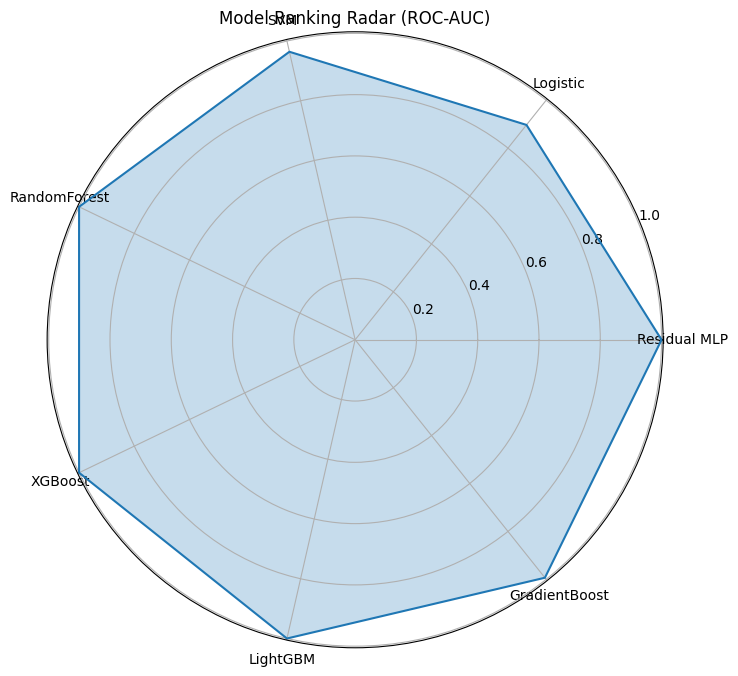

In [33]:
import matplotlib.pyplot as plt
import numpy as np

metrics_for_radar = ["mean_auc"]

labels = list(results_detailed.keys())
values = [results_detailed[m]["mean_auc"] for m in labels]

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)

fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))

values_cycle = np.concatenate((values, [values[0]]))
angles_cycle = np.concatenate((angles, [angles[0]]))

ax.plot(angles_cycle, values_cycle)
ax.fill(angles_cycle, values_cycle, alpha=0.25)

ax.set_xticks(angles)
ax.set_xticklabels(labels)
ax.set_title("Model Ranking Radar (ROC-AUC)")

plt.show()

In [34]:
confusion_summary = {}

for name in results_detailed:

    y_true = results_detailed[name]["y_true"]
    y_pred = (results_detailed[name]["y_prob"] > 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    confusion_summary[name] = {
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn
    }

confusion_df = pd.DataFrame(confusion_summary).T
confusion_df


,TP,FP,FN,TN
Residual MLP,526,0,0,499
Logistic,464,108,62,391
SVM,488,56,38,443
RandomForest,526,0,0,499
XGBoost,526,0,0,499
LightGBM,526,0,0,499
GradientBoost,514,14,12,485
